### Libraries.

In [ ]:
import itertools
import sys

from anndata import AnnData
from matplotlib import rcParams
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scanpy as sc
from sklearn.preprocessing import OneHotEncoder
import torch
from tqdm import tqdm

from sc_exp_design.config import NeuralVelocityFieldConfig
from sc_exp_design.models import FlowMatching

sys.path.insert(0, "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/scripts")
from fetch_data import fetch_adata_goattgens_sfc, EXPERIMENTAL_COLUMNS

# defining figure size
FIGSIZE = (3, 3)
rcParams["figure.figsize"] = FIGSIZE


### Data.

In [ ]:
ADATA_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/gdrive/HID01_fcs_concatenated_logicle.h5ad"
adata = fetch_adata_goattgens_sfc(
    ADATA_PATH,
    mode="log_transformed",
    uns_key_added="one_hot",
)
adata


AnnData object with n_obs × n_vars = 93275454 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps'
    obsm: 'X_repr', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[

### Subsampling.

In [ ]:
# optionally subsample the data
KEEP_COPY = True
SUBSAMPLE = True
SUBSAMPLING_DONE = False
SUBSAMPLE_SIZE = 1e-2

if SUBSAMPLE and not SUBSAMPLING_DONE:
    if KEEP_COPY:
        adata_original = adata.copy()
        sc.pp.subsample(adata, SUBSAMPLE_SIZE)
    SUBSAMPLING_DONE = True
adata


AnnData object with n_obs × n_vars = 932754 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps'
    obsm: 'X_repr', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm

### Initializing flow model.

In [ ]:
flow_matching = FlowMatching(
    coupling_type="independent",
    generate_from_noise=True,
)


### Prepare Data (Directly channel features).

In [ ]:
USE_PCA = False
USE_COND_CONCAT = True
flow_matching.prepare_train_data(
    adata,
    sample_rep="X_pca" if USE_PCA else None,
    control_key=None,
    perturbations=("cond_concat") if USE_COND_CONCAT else EXPERIMENTAL_COLUMNS,
    perturbations_in_obsm=("cond_concat") if USE_COND_CONCAT else EXPERIMENTAL_COLUMNS,
    perturbation_reps={"cond_concat": "cond_concat"} if USE_COND_CONCAT else{e:e for e in EXPERIMENTAL_COLUMNS},
)


### Initialize Velocity Field.

In [ ]:
column = "cond_concat"
cvf_config = NeuralVelocityFieldConfig(
    flow_dim=adata.obsm["X_pca"].shape[1] if USE_PCA else adata.X.shape[1],
    encode_state=True,
    state_encoder_output_dim=64,
    state_encoder_mlp_kwargs={
        "hidden_dims": (64,),
        "use_batchnorm": False,
        "use_dropout": False,
        "dropout_rate": 0.0,
        "activation_class": torch.nn.SELU,
        "final_activation_class": torch.nn.Identity,
    },
    use_guidance=True,
    encode_conditions=True,
    perturbation_layers_before_pooling= {
        f"feats_cond_concat_cond_concat":{
            "input_dim": len(EXPERIMENTAL_COLUMNS),
            "output_dim": 16,
            "hidden_dims": (64, ),
            "use_batchnorm": False,
            "use_dropout": False,
            "dropout_rate": 0.0,
            "activation_class": torch.nn.SELU,
            "final_activation_class": torch.nn.Identity,
        }
    } else {
        f"feats_{column}_{column}":{
            "input_dim": 1,
            "output_dim": 16,
            "hidden_dims": (64, ),
            "use_batchnorm": False,
            "use_dropout": False,
            "dropout_rate": 0.0,
            "activation_class": torch.nn.SELU,
            "final_activation_class": torch.nn.Identity,
        } for column in EXPERIMENTAL_COLUMNS
    },
    perturbation_layers_after_pooling={
        "hidden_dims": (32, ),
        "use_batchnorm": False,
        "use_dropout": False,
        "dropout_rate": 0.0,
        "activation_class": torch.nn.SELU,
        "final_activation_class": torch.nn.Identity,
    },
    decoder_mlp_kwargs={
        "hidden_dims": (128, 128),
        "use_batchnorm": False,
        "use_dropout": False,
        "dropout_rate": 0.0,
        "activation_class": torch.nn.SELU,
        "final_activation_class": torch.nn.Identity,
    },
)
flow_matching.prepare_model(
    cvf_config,
    num_time_steps=100,
)


SyntaxError: invalid syntax (1491712156.py, line 27)

### Training the model.

Loss: 0.2912: 100%|██████████| 50000/50000 [03:19<00:00, 250.81it/s]


(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

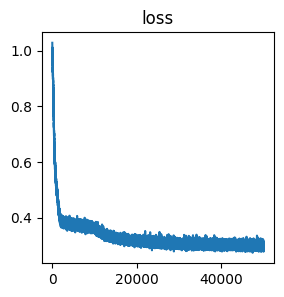

In [ ]:
flow_matching.train(
    num_training_steps=500_000,
)
flow_matching.trainer.plot_training_logs()


### Retrieving all possible combination of unique values for each experimental covariate.

In [ ]:
perturbation_data = flow_matching.train_data.perturbation_data
perturbation_covariates = list(perturbation_data.keys())
perturbation_val = np.concatenate(list([perturbation_data[cov] for cov in perturbation_covariates]), axis=-1)
combs = np.unique(perturbation_val, axis=0)
print(combs.shape)


(77, 13)


### Sampling from each combination.

In [ ]:
N_SAMPLES_PER_COMB = 10_000
if USE_COND_CONCAT:
    comb = torch.from_numpy(combs).float().to(flow_matching.device)
    cell_states = flow_matching.predict(
        {
            "condition": {f"feats_{column}_{column}": comb}
        },
        num_samples=N_SAMPLES_PER_COMB,
    ).detach().cpu().numpy()
    cell_states.shape
    cell_states_per_comb = {
        comb_id: cell_states[:, comb_id, :] for comb_id in range(combs.shape[0])
    }
else:

    cell_states_per_comb = {}
    for comb_id in tqdm(range(combs.shape[0])):
        comb = torch.from_numpy(combs[comb_id][None, :]).repeat(N_SAMPLES_PER_COMB, 1).float().to(flow_matching.device)
        cond = {cov_name: comb[:, idx].unsqueeze(-1) for idx, cov_name in enumerate(perturbation_covariates)}
        cell_states_per_comb[comb_id] = flow_matching.predict(
            {
                "condition": cond
            }
        ).detach().cpu().numpy()


### Reading subsampled adata for faster plotting.

In [ ]:
SMALL_ADATA_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/gdrive/ds_HID01_logicle_100k_UMAP_ann.h5ad"
small_adata = fetch_adata_goattgens_sfc(
    SMALL_ADATA_PATH,
    mode="log_transformed",
    uns_key_added="one_hot",
)
small_data = flow_matching.data_manager.get_data(small_adata)
small_perturbation_data = small_data.perturbation_data
small_perturbation_covariates = list(small_perturbation_data.keys())
small_perturbation_val = np.concatenate(list([small_perturbation_data[cov] for cov in small_perturbation_covariates]), axis=-1)
small_adata



AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
    obsm: 'X_pca', 'X_umap', 'X_repr', 'mtg_[µm]', 'rhflt3l_[ng

### KDE plot per channel feat and cond.

0


1


2


  0%|          | 0/50000 [21:29<?, ?it/s]


3


4


5


6


7


8


9


10


11


12


13


14


15


16


17


18


19


/tmp/ipykernel_316550/2680459101.py:7: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, data_real.shape[1], figsize=(45, 5))


20


21


22


23


24


25


26


27


28


29


30


31


32


33


34


35


36


37


38


39


40


41


42


43


44


45


46


47


48


49


50


51


52


53


54


55


56


57


58


59


60


61


62


63


64


65


66


67


68


69


70


71


72


73


74


75


76


100%|██████████| 77/77 [00:52<00:00,  1.46it/s]


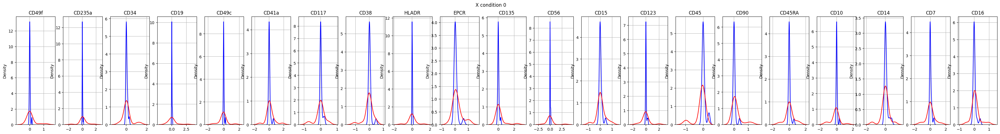

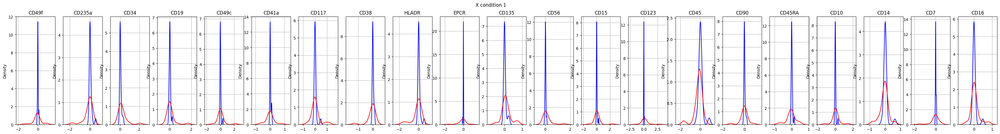

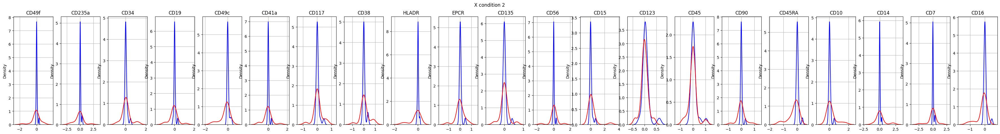

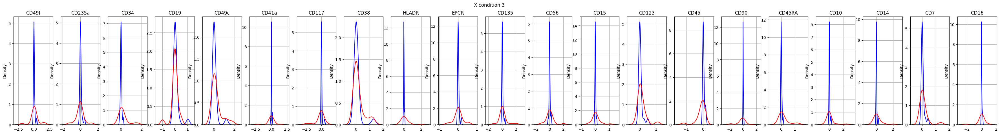

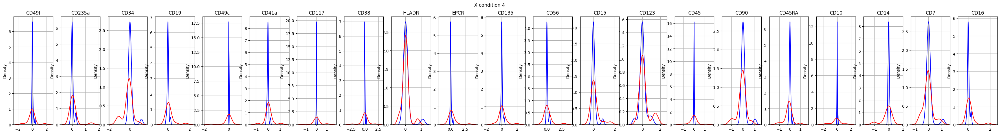

...

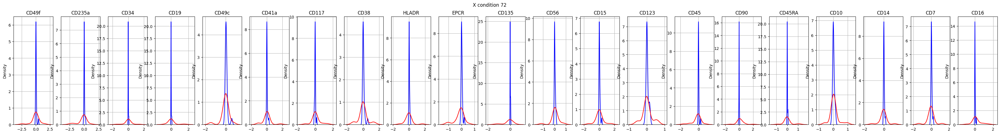

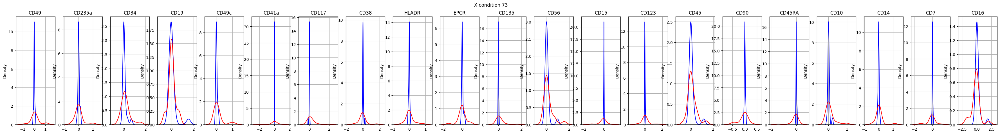

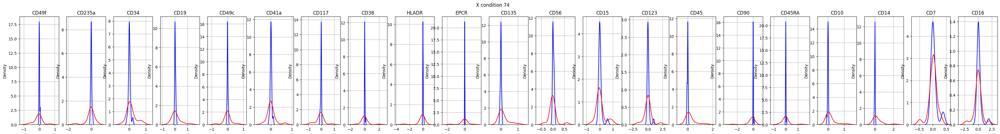

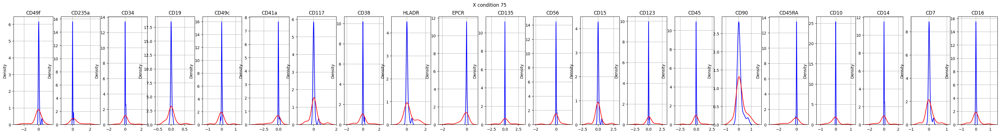

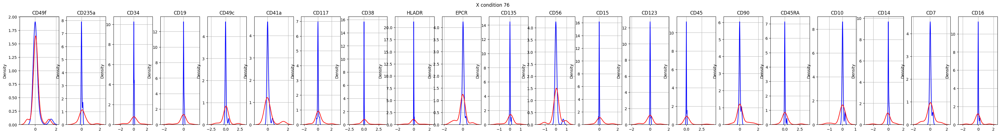

In [ ]:
int2antibody = {
    idx: small_adata.var.iloc[idx][["antibody"]].values[0] for idx in range(adata.var.shape[0])
}
antibody2idx = {v:k for k, v in int2antibody.items()}

def plot_kde_channels(data_real, data_gen, title=""):    
    fig, axes = plt.subplots(1, data_real.shape[1], figsize=(45, 5))
    fig.suptitle(f"X {title}")
    for idx in range(data_real.shape[1]):
        antibody = int2antibody[idx]
        sns.kdeplot(data_real[idx], ax=axes[idx], color="blue")
        sns.kdeplot(data_gen[idx], ax=axes[idx], color="red")
        axes[idx].grid(True)
        axes[idx].set_title(antibody)
    fig.show()

for comb_id, cell_states in tqdm(cell_states_per_comb.items()):
    cond = combs[comb_id]
    idxs = np.unique(np.argwhere(np.all(small_perturbation_val == cond, axis=-1)))
    print(comb_id)
    plot_kde_channels(small_adata.X[idxs], cell_states, title=f"condition {comb_id}")



### Iterating over each condition and visualizing predictions.

  0%|          | 0/77 [00:00<?, ?it/s]

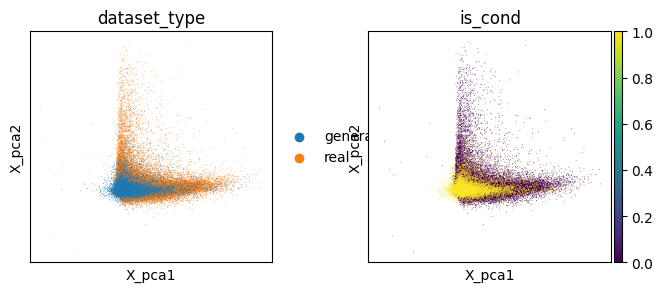

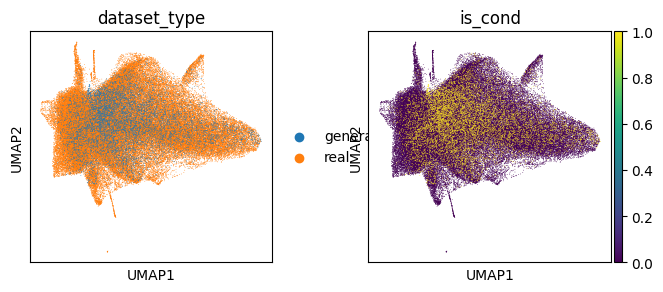

  1%|▏         | 1/77 [01:09<1:27:58, 69.45s/it]

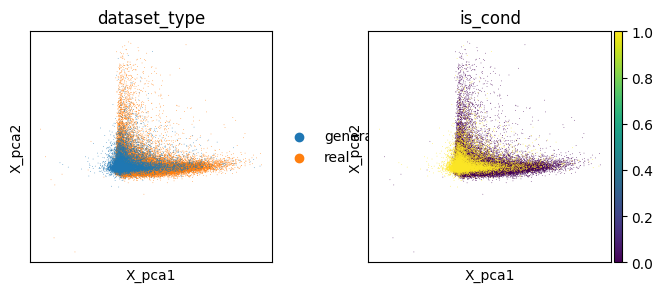

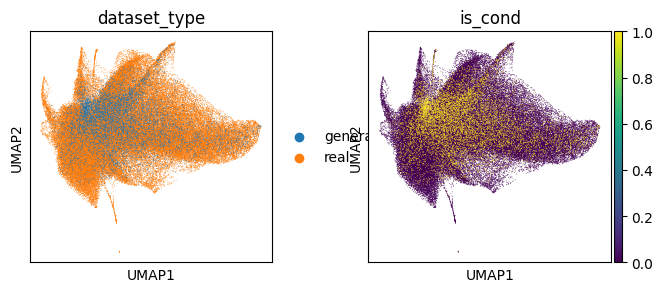

  3%|▎         | 2/77 [02:12<1:22:01, 65.62s/it]

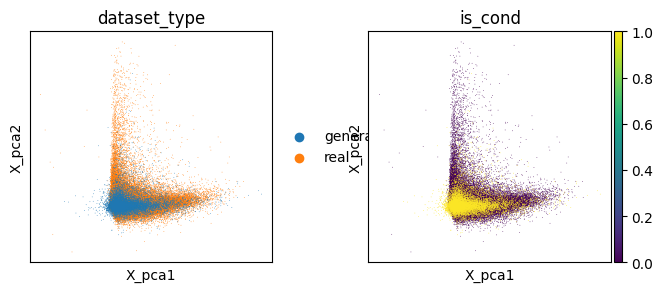

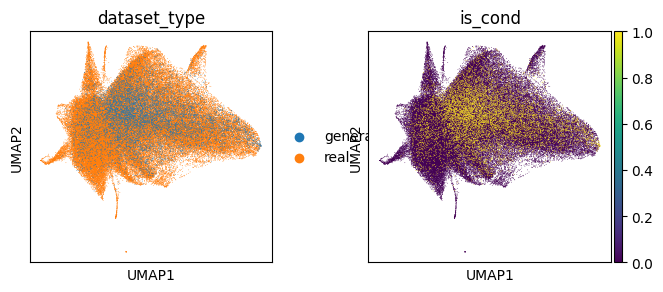

  4%|▍         | 3/77 [04:01<1:39:15, 80.48s/it]


KeyboardInterrupt: 

In [ ]:
for comb_id, cell_states in tqdm(cell_states_per_comb.items()):
    cond = combs[comb_id]
    idxs = np.unique(np.argwhere(np.all(small_perturbation_val == cond, axis=-1)))
    is_cond = np.zeros((len(small_adata)))
    is_cond[idxs] = 1
    is_cond = is_cond.tolist()

    X = np.concatenate([small_adata.X, cell_states], axis=0)
    dataset_type = ["real" for _ in range(len(small_adata))] + ["generated" for _ in range(N_SAMPLES_PER_COMB)]
    is_cond = is_cond + [True for _ in range(N_SAMPLES_PER_COMB)]
    adata_cond = sc.AnnData(X=X, obs={"dataset_type": dataset_type, "is_cond": is_cond})

    sc.pp.pca(adata_cond)
    sc.pp.neighbors(adata_cond)
    sc.tl.umap(adata_cond)
    sc.pl.embedding(adata_cond, "X_pca", color=["dataset_type", "is_cond"])
    sc.pl.embedding(adata_cond, "umap", color=["dataset_type", "is_cond"])
